In [1]:
from pyDOE import *
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math 
from torch.autograd import grad
from data_generator import Schrodinger_Boundary, Schrodinger_Initial, Schrodinger

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch utilizing dev",device)

Torch utilizing dev cpu


# Training data

In [2]:
'''
class Schrodinger_Boundary(Dataset):
    def __init__(self, num_col_bound = 50):  
        self.num_col_bound = num_col_bound
        num_col_bound_half = math.floor(num_col_bound/2)
        self.t = torch.tensor(np.squeeze(lhs(1,num_col_bound=num_col_bound_half)*math.pi/2), requires_grad=True).float().to(device)
        return
    def __getitem__(self,idx):
        return self.t[idx]
    def __len__(self):
        return len(self.t)
    def getall(self):
        return self.t
    
class Schrodinger_Initial(Dataset):
    def __init__(self, num_h_init = 50):            
        h_func = lambda x : 2 * (1/torch.cosh(x))
        self.num_h_init = num_h_init
        self.x = torch.tensor((lhs(1,num_h_init=num_h_init)*10 - 5), requires_grad=True).float().to(device)
        self.h = torch.squeeze(torch.stack((
            torch.tensor(h_func(self.x)).float().to(device),
            torch.zeros((len(self.x),1)).to(device)
        ),1))
        return
    def __getitem__(self,idx):
        return self.x[idx], self.h[idx]
    def __len__(self):
        return len(self.x)
    def getall(self):
        return self.x,self.h

class Schrodinger(Dataset):
    def __init__(self, num_col_schro = 20000): # returns x,t
        self.num_col_schro = num_col_schro
        x = torch.tensor(lhs(1,num_col_schro=num_col_schro)*10 - 5,requires_grad=True).float().to(device)
        t = torch.tensor(lhs(1,num_col_schro=num_col_schro)*(math.pi/2),requires_grad=True).float().to(device)
        self.X = torch.squeeze(torch.dstack((x,t))).float()
        return 
    def __getitem__(self,idx):
        return self.X[idx]
    def __len__(self):
        return len(self.X)
    def getall(self):
        return self.X
'''

boundary_ds = Schrodinger_Boundary(num_col_bound=50)
initial_ds = Schrodinger_Initial(num_h_init=50)
schrodinger_ds = Schrodinger(num_col_schro=20000)

schrodinger_dl = DataLoader(schrodinger_ds, batch_size=4096, shuffle=True)

c:\Users\Lorenz\Masterthesis\Git\ZnPINNLab\day2\data_generator.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(h_func(self.x)).float().to(device),


In [ ]:
def create_training_data(
        time_vals, 
        position_vals, 
        num_t_train = 20,  
        max_t_train = time[-1],
        min_t_train = 0,
        num_t_col = 100,
    ):
    """
    Create training data for training procedure.

    This function generates training data using a subset
    of time values ('time_vals' tensor) and corresponding 
    x- and y-components ('position_vals' tensor).
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'time_vals' and 'position_vals' arrays:

            - Create a tensor 'all_idx' containing indices between 0 
              and time_vals[-1]*100 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and max_t_train*100 to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 't_train', 'x_train', and 'y_train' tensors by selecting index values 'idx_train' 
              from 'time_vals' and 'position_vals'.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
            - Format the tensor size as 'torch.Size([num_t_train, 1])' by applying the .unsqueeze(1) method.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.
    
    Step 4: Colocation points
            Build 't_col', a tensor that includes 'num_t_col' evenly spaced Values 
            between 0 and the last value in 'time_vals'.

    Step 5: Dataset Creation
            Create datasets train_ds and test_ds by using dictionaries 
            containing "inputs", "targets_x", "targets_y" and "t_col"(if already defined) entries.
        
    Step 6:  Return the created datasets.
    
    Parameters
    ----------
    time_vals : torch.Tensor
        A tensor containing time values.
    position_vals : torch.Tensor
        A tensor containing x- and y-components of the displacement vector.
    num_t_train : int, optional
        The number of data points to select from the provided time. Default is 10.
    max_t_train : float, optional
        The maximum time value to include in the training data. Default is 2.
    min_t_train : float, optional
        The minimum time value to include in the training data. Default is 0.
    num_t_col : int, optional
        The number of evenly spaced time values to generate in 't_col'. Default is 100.
        
    Returns
    -------
    Dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries for training data.
    Dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries for testing data.
    """
    
    # Step 1: Create a tensors of indices that correspond to the selected time values.
    all_idx = torch.arange(0, time_vals[-1]*100, dtype=torch.int)
    idx_train = torch.linspace(min_t_train*100, max_t_train*100, num_t_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: - Get t_train, x_train and y_train by selecting values from the provided data.
    t_train = time_vals[idx_train].clone().detach().unsqueeze(1)
    x_train = position_vals[idx_train, 0].clone().detach().unsqueeze(1)
    y_train = position_vals[idx_train, 1].clone().detach().unsqueeze(1)

    
    # Step 3: Get t_test, x_test, y_test from the provided data
    t_test = time_vals[idx_test].clone().detach().unsqueeze(1)
    x_test = position_vals[idx_test, 0].clone().detach().unsqueeze(1)
    y_test = position_vals[idx_test, 1].clone().detach().unsqueeze(1)

    # Step 4: Generate a t_col tensor with evenly spaced time Values in t_ime_vals and num_t_col steps
    t_col = torch.linspace(0, time_vals[-1], num_t_col).unsqueeze(1)
    
    # Step 5: Create datasets train_ds and test_ds by using dictionaries 
    train_ds = {"inputs": t_train, "targets_x": x_train,"targets_y": y_train, "t_col": t_col}
    test_ds = {"inputs": t_test, "targets_x": x_test, "targets_y": y_test, "t_col": t_col}

    # Step 6: return datasets
    return train_ds, test_ds


# Train PINN on Non-Linear Schrodinger's Equation

$ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 

Boundary conditions

*   $h(t,5)=h(t,-5)$ 

*   $h_{x}(t,5)=h_{x}(-t,5)$

Regularization


* $f(x,t) = ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 
 

Neural network approximates $h(x,t)$ with real-numbered u,v outputs representing the real and complex parts respectively. MSE for complex & real parts are calculated separately without use of PyTorch complex numbers



Trained over 20,000 epochs at lr=0.0025 using CUDA

Epoch 0 ~ Train Loss 5.226435661315918
Epoch 5 ~ Train Loss 0.2151307463645935
Epoch 10 ~ Train Loss 0.6836357712745667
Epoch 15 ~ Train Loss 0.2502668499946594
Epoch 20 ~ Train Loss 0.1966412514448166
Final Loss:  tensor(0.1908, grad_fn=<AddBackward0>)


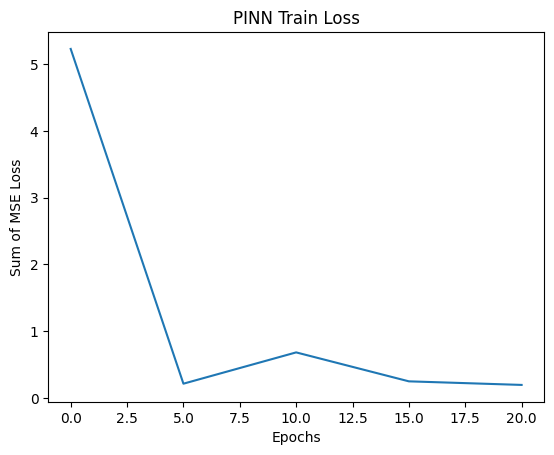

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()        
        # NN layers
        self.dense1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.dense1.weight)
        self.dense2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.dense2.weight)
        self.dense3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.dense3.weight)
        self.dense4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.dense4.weight)
        self.dense5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.dense5.weight)
        self.dense6 = nn.Linear(100,2).to(device)
        torch.nn.init.xavier_uniform_(self.dense6.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass

    def forward(self,X):
        x = self.dense1(X)
        x = torch.tanh(x)      
        x = self.dense2(x)
        x = torch.tanh(x)     
        x = self.dense3(x)
        x = torch.tanh(x)      
        x = self.dense4(x)
        x = torch.tanh(x)     
        x = self.dense5(x)
        x = torch.tanh(x)     
        x = self.dense6(x)
        return x
    
    def h(self, x, t):
        X = torch.cat((x,t),1).float().to(device)
        return self.forward(X)

    def norm(self, real, compl):
      return torch.sqrt((real**2) + (compl**2))

    def loss(self):
        
        # Initial Condition: h(x,0) = 2sech(x)
        X_0,H_0 = initial_ds.getall()
        zeros = torch.zeros((len(X_0),1)).float().to(device)

        h = self.h(X_0,zeros)
        h_r = h[:,0]
        h_c = h[:,1]
         
        J_0 = torch.mean((H_0 - h)**2)

        # Function Condition ih_t + 0.5h_xx + h(|h|**2) = 0
        X = schrodinger_ds.getall()
        x = torch.unsqueeze(X[:,0], 1)
        t = torch.unsqueeze(X[:,1], 1)

        _h = self.h(x,t)

        hf_r = torch.unsqueeze(_h[:,0],1)
        hf_c = torch.unsqueeze(_h[:,1],1)
        
        h_fx_r = grad(outputs=hf_r, inputs=x, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
        h_fxx_r = grad(outputs=h_fx_r, inputs=x, grad_outputs=torch.ones_like(h_fx_r), create_graph=True)[0]
        h_ft_r = grad(outputs=hf_r, inputs=t, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
        
        h_fx_c = grad(outputs=hf_c, inputs=x, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]
        h_fxx_c = grad(outputs=h_fx_c, inputs=x, grad_outputs=torch.ones_like(h_fx_c), create_graph=True)[0]
        h_ft_c = grad(outputs=hf_c, inputs=t, grad_outputs=torch.ones_like(hf_c), create_graph=True)[0]

        f_r = (h_ft_r) + (0.5 * h_fxx_c) + (((hf_r**2)+(hf_c**2))*hf_c)   
        f_c = (h_ft_c) - (0.5 * h_fxx_r) - (((hf_r**2)+(hf_c**2))*hf_r) 
        
        J_f = torch.mean(self.norm(f_r,f_c)**2)

        # # Boundary conditions
        tb = torch.unsqueeze(boundary_ds.getall(),1)
        fives = torch.ones((len(tb),1), requires_grad=True).to(device)*5.

        hp = self.h(fives,tb)
        hn = self.h(-fives,tb)

        hp_r = hp[:,0]
        hn_r = hn[:,0]
        hp_c = hp[:,1]
        hn_c = hn[:,1]

        hp_r_x = grad(outputs=hp_r, inputs=fives, grad_outputs=torch.ones_like(hp_r), create_graph=True)[0]
        hp_c_x = grad(outputs=hp_c, inputs=fives, grad_outputs=torch.ones_like(hp_c), create_graph=True)[0]

        hn_r_x = grad(outputs=hn_r, inputs=fives, grad_outputs=torch.ones_like(hn_r), create_graph=True)[0]
        hn_c_x = grad(outputs=hn_c, inputs=fives, grad_outputs=torch.ones_like(hn_c), create_graph=True)[0]
        
        h_r_err = torch.unsqueeze(hp_r - hn_r,1)
        h_c_err = torch.unsqueeze(hp_c - hn_c,1)

        h_xr_err = hp_r_x - hn_r_x
        h_xc_err = hp_c_x - hn_c_x

        h_err = (h_r_err**2) + (h_c_err**2)
        h_x_err = (h_xr_err**2) + (h_xc_err**2)

        J_B = torch.mean( (h_err**2) + (h_x_err**2) )

        return J_0 + J_B + J_f 
        
    def train(self,epochs,display_every_n_epochs):
        history = []
        epoch_hist = []
        for i in range(0, epochs):
            self.zero_grad()
            loss = self.loss()
            loss.backward()
            self.optimizer.step()
            if(i % display_every_n_epochs == 0):
                print("Epoch", i, "~ Train Loss" , loss.item())
                history.append(loss.item())
                epoch_hist.append(i)
        print("Final Loss: ", loss)
        return epoch_hist, history
    
_nn = PINN().to(device)
epochs,hist = _nn.train(epochs=25,display_every_n_epochs=5)

plt.plot(epochs,hist)
plt.xlabel("Epochs")
plt.ylabel("Sum of MSE Loss") 
plt.title("PINN Train Loss")
plt.show() 


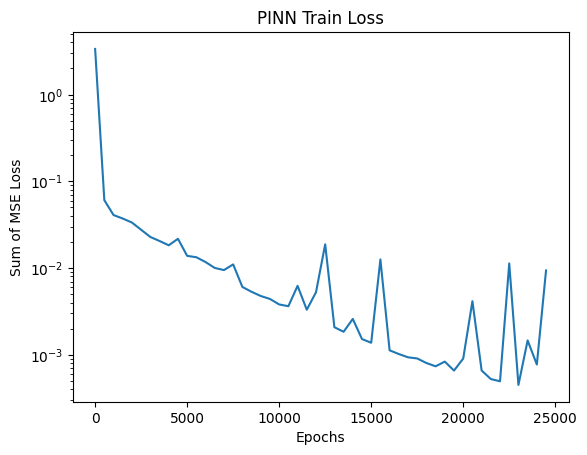

In [15]:
plt.plot(epochs,hist)
plt.xlabel("Epochs")
plt.ylabel("Sum of MSE Loss") 
plt.title("PINN Train Loss")
plt.yscale("log")
plt.show() 

# Plot results & approximated solution



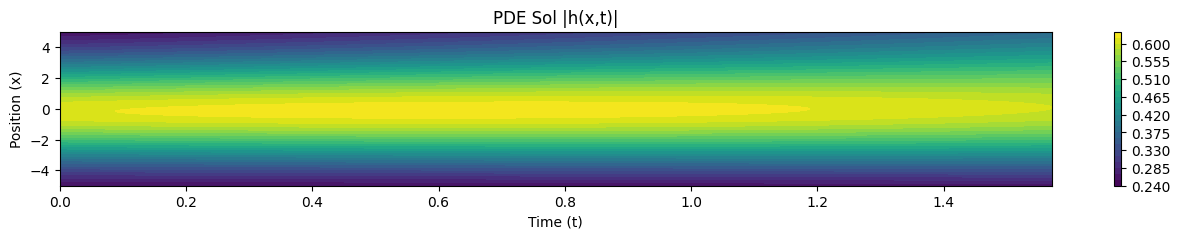

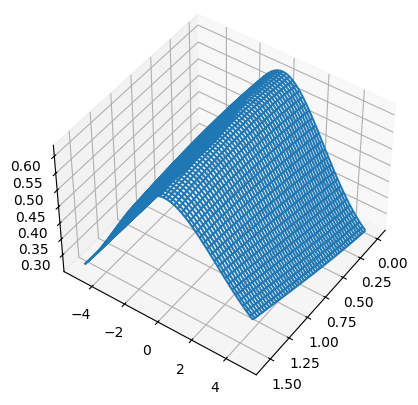

Text(0, 0.5, '|h(t,x)|')

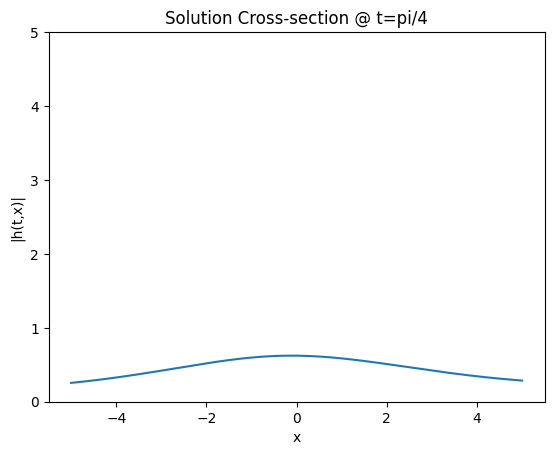

In [7]:
%matplotlib inline

x = np.linspace(-5,5,300)
t = np.linspace(0,math.pi/2,300)

X,T = np.meshgrid(x,t)

_X = torch.tensor(np.dstack((X,T))).float().to(device)

h_hat = _nn.forward(_X).to('cpu').detach().numpy()

h_norm = np.sqrt((h_hat[:,:,0] ** 2) + (h_hat[:,:,1] ** 2))

fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,h_norm, 30)
plt.colorbar(cf)

plt.title('PDE Sol |h(x,t)|')
plt.ylabel("Position (x)")
plt.xlabel("Time (t)")
plt.show()

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(T, X, h_norm, cmap='binary')
ax.view_init(45, 35)
plt.show()

x_slice = x[:]
h_slice = h_norm[100,:]

plt.ylim(0,5)

plt.plot(x_slice,h_slice)
plt.title('Solution Cross-section @ t=pi/4')
plt.xlabel('x')
plt.ylabel('|h(t,x)|')